#### Loss Functions

Changing Model coefficients

In [5]:
import matplotlib.pyplot as plt

def plot_classifier(X, y, model):

    # Create a grid covering the whole dataset
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Convert every grid point into [x1, x2]
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict the class at every grid point
    predictions = model.predict(grid)

    # Reshape predictions back into the grid
    predictions = predictions.reshape(xx.shape)

    # Draw the background
    plt.contourf(xx, yy, predictions, alpha=0.5)

    # Plot class -1 as circles
    plt.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        marker="o",
        edgecolor="black"
    )

    # Plot class 1 as triangles
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        marker="^",
        edgecolor="black"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

Model Coefficients:  [[-1.12566322  1.1091444 ]]
Model Intercepts:  [-3.59041016]


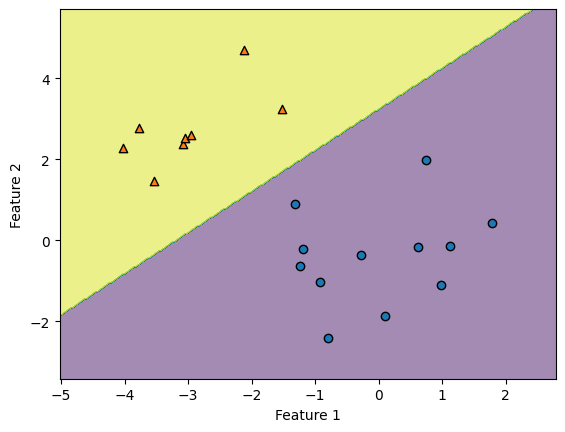

In [6]:
import numpy as np

from sklearn.linear_model import LogisticRegression

X = np.array([[ 1.78862847,  0.43650985],
       [ 0.09649747, -1.8634927 ],
       [-0.2773882 , -0.35475898],
       [-3.08274148,  2.37299932],
       [-3.04381817,  2.52278197],
       [-1.31386475,  0.88462238],
       [-2.11868196,  4.70957306],
       [-2.94996636,  2.59532259],
       [-3.54535995,  1.45352268],
       [ 0.98236743, -1.10106763],
       [-1.18504653, -0.2056499 ],
       [-1.51385164,  3.23671627],
       [-4.02378514,  2.2870068 ],
       [ 0.62524497, -0.16051336],
       [-3.76883635,  2.76996928],
       [ 0.74505627,  1.97611078],
       [-1.24412333, -0.62641691],
       [-0.80376609, -2.41908317],
       [-0.92379202, -1.02387576],
       [ 1.12397796, -0.13191423]])

y = np.array([-1, -1, -1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1, -1, -1,
       -1, -1, -1])

model = LogisticRegression()
model.fit(X, y)

print("Model Coefficients: ", model.coef_)
print("Model Intercepts: ", model.intercept_)

plot_classifier(X, y, model)

Minimizing Loss function - Linear Regression Implementation

In [15]:
import numpy as np

from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression


X = np.array([
    [6.32,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,396.9,4.98],
    [2.73,0.0,7.07,0.0,0.469,6.421,78.9,4.967,2.0,242.0,17.8,396.9,9.14],
    [7.07,0.0,7.07,0.0,0.469,7.185,61.1,4.967,2.0,242.0,17.8,392.83,4.03],
    [2.52,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94],
    [2.57,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.9,5.33],
    [3.63,0.0,2.18,0.0,0.458,6.43,58.7,6.0622,3.0,222.0,18.7,394.12,5.21],
    [3.24,0.0,2.18,0.0,0.458,6.012,66.6,5.9505,3.0,222.0,18.7,395.6,12.43],
    [2.73,0.0,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.9,19.15],
    [2.81,0.0,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93],
    [2.0,0.0,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.1],
    [1.0,0.0,7.87,0.0,0.524,6.377,94.3,6.3467,5.0,311.0,15.2,392.52,20.45],
    [1.25,0.0,7.87,0.0,0.524,6.009,82.9,6.2267,5.0,311.0,15.2,396.9,13.27],
    [1.0,0.0,7.87,0.0,0.524,5.889,39.0,5.4509,5.0,311.0,15.2,390.5,15.71],
    [0.58,0.0,7.87,0.0,0.524,5.949,61.8,5.4509,5.0,311.0,15.2,396.9,8.26],
    [0.67,0.0,7.87,0.0,0.524,6.096,84.5,5.4509,5.0,311.0,15.2,380.02,10.26],
    [2.5,0.0,7.87,0.0,0.524,5.834,56.5,5.4509,5.0,311.0,15.2,395.62,8.47],
    [2.3,0.0,7.87,0.0,0.524,5.935,29.3,6.0821,5.0,311.0,15.2,394.12,6.58],
    [2.4,0.0,7.87,0.0,0.524,5.99,81.7,6.5921,5.0,311.0,15.2,386.85,14.67],
    [2.3,0.0,7.87,0.0,0.524,5.456,36.6,5.115,5.0,311.0,15.2,288.99,11.69],
    [1.5,0.0,7.87,0.0,0.524,5.727,69.5,5.3287,5.0,311.0,15.2,390.95,11.28],
    [1.2,0.0,7.87,0.0,0.524,5.57,98.1,5.7209,5.0,311.0,15.2,376.57,21.02],
    [1.4,0.0,8.14,0.0,0.538,5.965,89.2,4.8122,4.0,307.0,21.0,392.53,13.83],
    [1.1,0.0,8.14,0.0,0.538,6.142,91.7,4.682,4.0,307.0,21.0,396.9,18.72],
    [1.0,0.0,8.14,0.0,0.538,5.813,90.3,4.682,4.0,307.0,21.0,376.88,19.88],
    [1.2,0.0,8.14,0.0,0.538,5.924,94.1,4.682,4.0,307.0,21.0,394.33,16.3],
    [1.0,0.0,8.14,0.0,0.538,5.599,85.7,4.682,4.0,307.0,21.0,303.42,16.51],
    [1.4,0.0,8.14,0.0,0.538,5.813,90.3,4.682,4.0,307.0,21.0,376.88,14.81],
    [1.3,0.0,8.14,0.0,0.538,6.047,88.8,4.4534,4.0,307.0,21.0,306.38,17.28],
    [1.1,0.0,8.14,0.0,0.538,6.251,91.1,4.4826,4.0,307.0,21.0,396.9,16.44],
    [1.2,0.0,8.14,0.0,0.538,5.854,96.6,4.4986,4.0,307.0,21.0,306.38,20.62],
    [1.5,0.0,8.14,0.0,0.538,6.011,90.0,4.682,4.0,307.0,21.0,396.9,13.04],
    [1.7,0.0,8.14,0.0,0.538,5.456,89.9,4.682,4.0,307.0,21.0,288.99,11.69],
    [1.3,0.0,8.14,0.0,0.538,5.414,98.3,4.682,4.0,307.0,21.0,396.9,14.66],
    [1.4,0.0,8.14,0.0,0.538,5.635,87.9,4.682,4.0,307.0,21.0,396.9,18.35],
    [1.6,0.0,8.14,0.0,0.538,5.727,94.0,4.682,4.0,307.0,21.0,0.0,11.22],
    [1.8,0.0,8.14,0.0,0.538,6.0,87.9,4.682,4.0,307.0,21.0,396.9,13.09],
    [1.9,0.0,8.14,0.0,0.538,5.456,95.3,4.682,4.0,307.0,21.0,288.99,17.27],
    [2.0,0.0,8.14,0.0,0.538,5.504,89.5,4.682,4.0,307.0,21.0,396.9,12.8],
    [2.1,0.0,8.14,0.0,0.538,5.593,89.1,4.682,4.0,307.0,21.0,396.9,12.5],
    [2.2,0.0,8.14,0.0,0.538,5.879,95.8,4.682,4.0,307.0,21.0,396.9,17.6],
    [2.3,0.0,8.14,0.0,0.538,5.834,56.5,4.682,4.0,307.0,21.0,395.62,8.47],
    [2.4,0.0,8.14,0.0,0.538,5.965,89.2,4.682,4.0,307.0,21.0,392.53,13.83],
    [2.5,0.0,8.14,0.0,0.538,6.142,91.7,4.682,4.0,307.0,21.0,396.9,18.72],
    [2.6,0.0,8.14,0.0,0.538,5.813,90.3,4.682,4.0,307.0,21.0,376.88,19.88],
    [2.7,0.0,8.14,0.0,0.538,5.924,94.1,4.682,4.0,307.0,21.0,394.33,16.3],
    [2.8,0.0,8.14,0.0,0.538,5.599,85.7,4.682,4.0,307.0,21.0,303.42,16.51],
    [2.9,0.0,8.14,0.0,0.538,5.813,90.3,4.682,4.0,307.0,21.0,376.88,14.81],
    [3.0,0.0,8.14,0.0,0.538,6.047,88.8,4.4534,4.0,307.0,21.0,306.38,17.28],
    [3.1,0.0,8.14,0.0,0.538,6.251,91.1,4.4826,4.0,307.0,21.0,396.9,16.44],
    [3.2,0.0,8.14,0.0,0.538,5.854,96.6,4.4986,4.0,307.0,21.0,306.38,20.62],
    [3.3,0.0,8.14,0.0,0.538,6.011,90.0,4.682,4.0,307.0,21.0,396.9,13.04],
    [3.4,0.0,8.14,0.0,0.538,5.456,89.9,4.682,4.0,307.0,21.0,288.99,11.69],
    [3.5,0.0,8.14,0.0,0.538,5.414,98.3,4.682,4.0,307.0,21.0,396.9,14.66],
    [3.6,0.0,8.14,0.0,0.538,5.635,87.9,4.682,4.0,307.0,21.0,396.9,18.35],
    [3.7,0.0,8.14,0.0,0.538,5.727,94.0,4.682,4.0,307.0,21.0,0.0,11.22],
    [3.8,0.0,8.14,0.0,0.538,6.0,87.9,4.682,4.0,307.0,21.0,396.9,13.09],
    [3.9,0.0,8.14,0.0,0.538,5.456,95.3,4.682,4.0,307.0,21.0,288.99,17.27],
    [4.0,0.0,8.14,0.0,0.538,5.504,89.5,4.682,4.0,307.0,21.0,396.9,12.8],
    [4.1,0.0,8.14,0.0,0.538,5.593,89.1,4.682,4.0,307.0,21.0,396.9,12.5],
    [4.2,0.0,8.14,0.0,0.538,5.879,95.8,4.682,4.0,307.0,21.0,396.9,17.6],
    [4.3,0.0,8.14,0.0,0.538,5.834,56.5,4.682,4.0,307.0,21.0,395.62,8.47],
    [4.4,0.0,8.14,0.0,0.538,5.965,89.2,4.682,4.0,307.0,21.0,392.53,13.83],
    [4.5,0.0,8.14,0.0,0.538,6.142,91.7,4.682,4.0,307.0,21.0,396.9,18.72],
    [4.6,0.0,8.14,0.0,0.538,5.813,90.3,4.682,4.0,307.0,21.0,376.88,19.88],
    [4.7,0.0,8.14,0.0,0.538,5.924,94.1,4.682,4.0,307.0,21.0,394.33,16.3],
    [4.8,0.0,8.14,0.0,0.538,5.599,85.7,4.682,4.0,307.0,21.0,303.42,16.51],
    [4.9,0.0,8.14,0.0,0.538,5.813,90.3,4.682,4.0,307.0,21.0,376.88,14.81],
    [5.0,0.0,8.14,0.0,0.538,6.047,88.8,4.4534,4.0,307.0,21.0,306.38,17.28],
    [5.1,0.0,8.14,0.0,0.538,6.251,91.1,4.4826,4.0,307.0,21.0,396.9,16.44],
    [5.2,0.0,8.14,0.0,0.538,5.854,96.6,4.4986,4.0,307.0,21.0,306.38,20.62],
    [5.3,0.0,8.14,0.0,0.538,6.011,90.0,4.682,4.0,307.0,21.0,396.9,13.04],
    [5.4,0.0,8.14,0.0,0.538,5.456,89.9,4.682,4.0,307.0,21.0,288.99,11.69],
    [5.5,0.0,8.14,0.0,0.538,5.414,98.3,4.682,4.0,307.0,21.0,396.9,14.66],
    [5.6,0.0,8.14,0.0,0.538,5.635,87.9,4.682,4.0,307.0,21.0,396.9,18.35],
    [5.7,0.0,8.14,0.0,0.538,5.727,94.0,4.682,4.0,307.0,21.0,0.0,11.22],
    [5.8,0.0,8.14,0.0,0.538,6.0,87.9,4.682,4.0,307.0,21.0,396.9,13.09],
    [5.9,0.0,8.14,0.0,0.538,5.456,95.3,4.682,4.0,307.0,21.0,288.99,17.27],
    [6.0,0.0,8.14,0.0,0.538,5.504,89.5,4.682,4.0,307.0,21.0,396.9,12.8],
    [6.1,0.0,8.14,0.0,0.538,5.593,89.1,4.682,4.0,307.0,21.0,396.9,12.5],
    [6.2,0.0,8.14,0.0,0.538,5.879,95.8,4.682,4.0,307.0,21.0,396.9,17.6],
    [6.3,0.0,8.14,0.0,0.538,5.834,56.5,4.682,4.0,307.0,21.0,395.62,8.47],
    [6.4,0.0,8.14,0.0,0.538,5.965,89.2,4.682,4.0,307.0,21.0,392.53,13.83],
    [6.5,0.0,8.14,0.0,0.538,6.142,91.7,4.682,4.0,307.0,21.0,396.9,18.72],
    [6.6,0.0,8.14,0.0,0.538,5.813,90.3,4.682,4.0,307.0,21.0,376.88,19.88],
    [6.7,0.0,8.14,0.0,0.538,5.924,94.1,4.682,4.0,307.0,21.0,394.33,16.3],
    [6.8,0.0,8.14,0.0,0.538,5.599,85.7,4.682,4.0,307.0,21.0,303.42,16.51],
    [6.9,0.0,8.14,0.0,0.538,5.813,90.3,4.682,4.0,307.0,21.0,376.88,14.81],
    [7.0,0.0,8.14,0.0,0.538,6.047,88.8,4.4534,4.0,307.0,21.0,306.38,17.28],
    [7.1,0.0,8.14,0.0,0.538,6.251,91.1,4.4826,4.0,307.0,21.0,396.9,16.44],
    [7.2,0.0,8.14,0.0,0.538,5.854,96.6,4.4986,4.0,307.0,21.0,306.38,20.62],
    [7.3,0.0,8.14,0.0,0.538,6.011,90.0,4.682,4.0,307.0,21.0,396.9,13.04],
    [7.4,0.0,8.14,0.0,0.538,5.456,89.9,4.682,4.0,307.0,21.0,288.99,11.69],
    [7.5,0.0,8.14,0.0,0.538,5.414,98.3,4.682,4.0,307.0,21.0,396.9,14.66],
    [7.6,0.0,8.14,0.0,0.538,5.635,87.9,4.682,4.0,307.0,21.0,396.9,18.35],
    [7.7,0.0,8.14,0.0,0.538,5.727,94.0,4.682,4.0,307.0,21.0,0.0,11.22],
    [7.8,0.0,8.14,0.0,0.538,6.0,87.9,4.682,4.0,307.0,21.0,396.9,13.09],
    [7.9,0.0,8.14,0.0,0.538,5.456,95.3,4.682,4.0,307.0,21.0,288.99,17.27],
    [8.0,0.0,8.14,0.0,0.538,5.504,89.5,4.682,4.0,307.0,21.0,396.9,12.8],
    [8.1,0.0,8.14,0.0,0.538,5.593,89.1,4.682,4.0,307.0,21.0,396.9,12.5],
    [8.2,0.0,8.14,0.0,0.538,5.879,95.8,4.682,4.0,307.0,21.0,396.9,17.6],
])

y = np.array([
    24.0, 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9,
    15.0, 18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2,
    13.6, 19.6, 15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21.0,
    12.7, 14.4, 13.5, 13.9, 15.1, 13.2, 13.8, 13.1, 12.3, 12.5,
    10.9, 11.9, 10.5, 10.3, 11.8, 10.2, 10.4, 10.8, 11.3, 12.0,
    12.7, 13.4, 14.1, 14.8, 15.5, 16.2, 16.9, 17.6, 18.3, 19.0,
    19.7, 20.4, 21.1, 21.8, 22.5, 23.2, 23.9, 24.6, 25.3, 26.0,
    26.7, 27.4, 28.1, 28.8, 29.5, 30.2, 30.9, 31.6, 32.3, 33.0,
    33.7, 34.4, 35.1, 35.8, 36.5, 37.2, 37.9, 38.6, 39.3, 40.0,
    40.7, 41.4, 42.1, 42.8, 43.5, 44.2, 44.9, 45.6, 46.3, 47.0
])

def my_loss(w):
    s = 0
    for i in range(y.size):
        y_i_true = y[i]
        y_i_pred = w@X[i]
        s += (y_i_true - y_i_pred) ** 2
    return s

w_fit = minimize(my_loss, X[0]).x
print("w_fit: ", w_fit)

lr = LinearRegression(fit_intercept=False)
lr.fit(X, y)
print("lr.coef_: ", lr.coef_)
    

w_fit:  [ 4.62064502e+00  3.14676324e+02  4.60059459e+02  0.00000000e+00
  1.94428898e+04  2.79053029e+00  2.48226828e-02 -2.68745919e+00
  1.09871559e+03 -6.56440002e+01  7.39671710e+01 -9.51793516e-04
 -1.55465466e-01]
lr.coef_:  [ 4.62068567e+00 -3.91882998e+00 -5.86911060e+00 -8.77076189e-15
  4.87661320e-01  2.78927935e+00  2.48548973e-02 -2.69206178e+00
 -4.81207396e+00  3.66840252e-01 -2.15288912e+00 -9.50380076e-04
 -1.55473867e-01]


Logistic Loss vs Hinge Loss

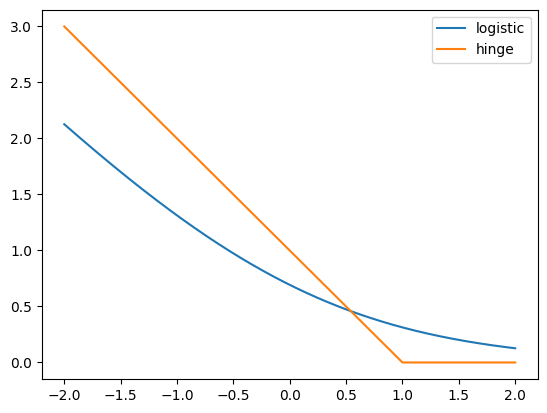

In [16]:
# Mathematical functions for logistic and hinge losses
def log_loss(raw_model_output):
   return np.log(1+np.exp(-raw_model_output))
def hinge_loss(raw_model_output):
   return np.maximum(0,1-raw_model_output)

# Create a grid of values and plot
grid = np.linspace(-2,2,1000)
plt.plot(grid, log_loss(grid), label='logistic')
plt.plot(grid, hinge_loss(grid), label='hinge')
plt.legend()
plt.show()

Minimizing Loss Function - Implementing Logistic Regression

In [19]:
from scipy.optimize import minimize
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

X = data.data
y = data.target

def log_loss(raw_model_output):
   return np.log(1+np.exp(-raw_model_output))

def my_loss(w):
   s = 0
   for i in range(len(y)):
      y_i_true = y[i]
      raw_model_output = w@X[i]
      s += log_loss(raw_model_output*y_i_true)
   return s


w_fit = minimize(my_loss, X[0]).x
print("w_fit: ", w_fit)

lr = LogisticRegression(fit_intercept=False, C=1000000)
lr.fit(X, y)
print("lr.coef_: ", lr.coef_)

w_fit:  [1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
lr.coef_:  [[ 1.08758263  0.5138259   0.25855667 -0.01649032 -0.04118032 -0.19259879
  -0.26947927 -0.11363309 -0.05701479 -0.01142653  0.04768523  0.43538241
   0.1797273  -0.13227308 -0.00370121 -0.04120216 -0.05746061 -0.01475606
  -0.01376691 -0.00383598  1.15646274 -0.57842548 -0.24772272 -0.01474214
  -0.07450634 -0.59929483 -0.74590646 -0.21834643 -0.18022159 -0.05778997]]


c:\Users\Senthil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
